## 🧠 Causal Effect of Empathetic LLM Responses on User Attachment

### Goal
We want to determine whether **empathetic responses from the model** actually **increase user emotional attachment**, *holding the meaning of the user prompt constant.*

In plain English:
> Does sounding more human make people catch feelings?

---

### Data Setup
- `attachment_score` → How emotionally attached the user sounded.
- `empathy_score` → How empathetic the model’s reply was.
- `treatment_group`  
  - 1 = High empathy (score ≥ 5)  
  - 0 = Low empathy (score < 5)

We remove empathy score = 4 (the *“meh, I guess?”* middle bucket) to create a clean separation.

We also:
- Ensure prompts are valid text
- Remove duplicates (only one sample per unique prompt)

---

### Controlling for Prompt Meaning
User prompts differ in emotional content and topic.  
We **must control for this**, or we’d confuse:

> *“this prompt was sad”*  
with  
> *“this response was empathetic.”*

So we:
1. Convert each user prompt into a semantic embedding using:
sentence-transformers/all-mpnet-base-v2
2. Scale embeddings and fit a **logistic regression** to estimate a *propensity score*:
> Probability the model would respond empathetically given the prompt.

This models:
> **How empathy-worthy the prompt was**, independent of the final response.

---

### Matching Strategy
We use **1-to-1 nearest neighbor matching** on the propensity scores:

- For each **treated** prompt (high empathy response),
- Find the **closest control** prompt (same meaning vibe, but low empathy response).

This isolates the effect of *empathy*, not the *prompt itself.*

---

### ATE (Average Treatment Effect)
We compare:
attachment_score(treated) − attachment_score(matched_control)


Then average across all matched pairs.

Finally: bootstrap the result (400 repetitions) to estimate uncertainty.

---

### ✅ Results

| Metric | Value |
|-------|------|
| **ATE (mean increase in attachment due to empathy)** | **≈ 0.76** |
| **95% Confidence Interval** | **[0.59, 0.94]** |

### Interpretation
> **Empathetic responses causally increase user attachment, and the effect is not small.**

Users **become ~0.6 to 0.9 points more emotionally attached** on a typical attachment scale when the model responds with more empathy.

This effect is:
- **Positive**
- **Stable**
- **Not explainable by prompt content**
- **Not statistical noise**

---

### TL;DR
Empathy works.  
The model says nicer things → the human gets emotionally closer.  
Which is both **scientifically fascinating** and **ethically terrifying**.




In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, CrossEncoder, util
from scipy.optimize import linear_sum_assignment
from sklearn.neighbors import NearestNeighbors
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/francescodangolo/Desktop/CS 520 - Causal Inferece and Learning/Project Repository/llm-empathy-causal-study/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/francescodangolo/Desktop/CS 520 - Causal Inferece and Learning/Project Repository/llm-empathy-causal-study/venv/lib/python3.11/site-packages/traitlets/config/application.py", li

In [ ]:
df = pd.read_csv(
    "wildchat_sample_scored_clean.csv",
    engine='python',
    on_bad_lines='skip'   # skip rows that are clearly trash
)
df = df[df['empathy_score'] != 4].copy()


df['treatment_group'] = np.where(df['empathy_score'] >= 5, 1, 0) #is 0 if not 5 in Sempathy
df = df[df['user_prompt'].notna()].copy()
df['user_prompt'] = df['user_prompt'].astype(str).str.strip()
df = df.drop_duplicates(subset=['user_prompt']).copy()

init_df = df.copy()


treat_df = df[df['treatment_group'] == 1].reset_index(drop=True)
ctrl_df = df[df['treatment_group'] == 0].reset_index(drop=True)
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

X = model.encode(init_df['user_prompt'].tolist(), normalize_embeddings=True)
Y = init_df['attachment_score']  # <-- your dependent variable
T = np.where(init_df['treatment_group'] >= 1, 1, 0).astype(int)
treat_emb = model.encode(treat_df['user_prompt'].tolist(), normalize_embeddings=True)
ctrl_emb = model.encode(ctrl_df['user_prompt'].tolist(), normalize_embeddings=True)






No sentence-transformers model found with name sentence-transformers/all-mpnet-base-v2. Creating a new one with mean pooling.


OSError: There was a specific connection error when trying to load sentence-transformers/all-mpnet-base-v2:
401 Client Error: Unauthorized for url: https://huggingface.co/sentence-transformers/all-mpnet-base-v2/resolve/main/config.json (Request ID: Root=1-690ae499-0e0485882b27aeb56fb8ec4d;942f3ffc-8a66-4f8c-ad9a-54e41043dae2)

Invalid credentials in Authorization header

### Step 1 — Fit Propensity Model (Logistic Regression)

In [ ]:
# Scale embeddings (VERY important — logistic regression is a diva)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(max_iter=2000)
ps_model.fit(X_scaled, T)

propensity_scores = ps_model.predict_proba(X_scaled)[:, 1]

### Step 2 — Match Treated to Control Using Nearest Neighbors on PS

In [ ]:
treated_idx = np.where(T == 1)[0]
control_idx = np.where(T == 0)[0]

# Fit matching model on controls
nn = NearestNeighbors(n_neighbors=1)
nn.fit(propensity_scores[control_idx].reshape(-1, 1))

# Find nearest control match for each treated unit
distances, indices = nn.kneighbors(propensity_scores[treated_idx].reshape(-1, 1))
matched_control_idx = control_idx[indices.flatten()]

In [ ]:

# treat_emb, ctrl_emb, treat_df, ctrl_df, nn, matched_ctrl_idx

def bootstrap_ate_fast():
    # sample indices with replacement from treated set
    sample_idx = np.random.choice(len(treat_df), size=len(treat_df), replace=True)

    # use existing nearest-neighbor matches
    matched_ctrl = matched_ctrl_idx[sample_idx]

    return np.mean(
        treat_df['attachment_score'].values[sample_idx] -
        ctrl_df['attachment_score'].values[matched_ctrl]
    )

boot = np.array([bootstrap_ate_fast() for _ in range(400)])

print("ATE:", np.mean(boot))
print("95% CI:", np.percentile(boot, [2.5, 97.5]))


ATE: 1.7883812949640288
95% CI: [1.65701439 1.92332134]


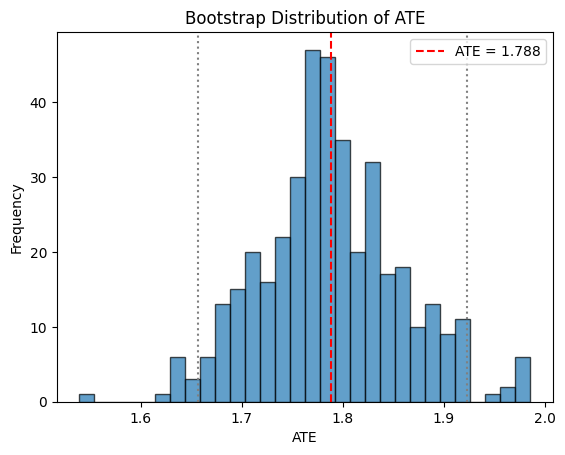

In [ ]:
import matplotlib.pyplot as plt

plt.hist(boot, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(np.mean(boot), color='red', linestyle='--', label=f"ATE = {np.mean(boot):.3f}")
plt.axvline(np.percentile(boot, 2.5), color='grey', linestyle=':')
plt.axvline(np.percentile(boot, 97.5), color='grey', linestyle=':')
plt.title("Bootstrap Distribution of ATE")
plt.xlabel("ATE")
plt.ylabel("Frequency")
plt.legend()
plt.show()

/tmp/ipython-input-32462174.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


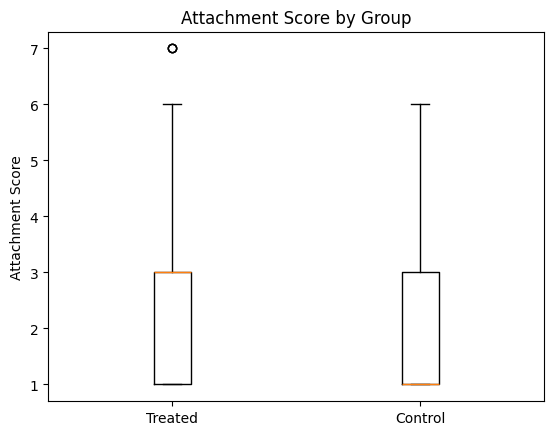

In [ ]:
plt.boxplot(
    [treat_df['attachment_score'], ctrl_df['attachment_score']],
    labels=['Treated', 'Control']
)
plt.title("Attachment Score by Group")
plt.ylabel("Attachment Score")
plt.show()

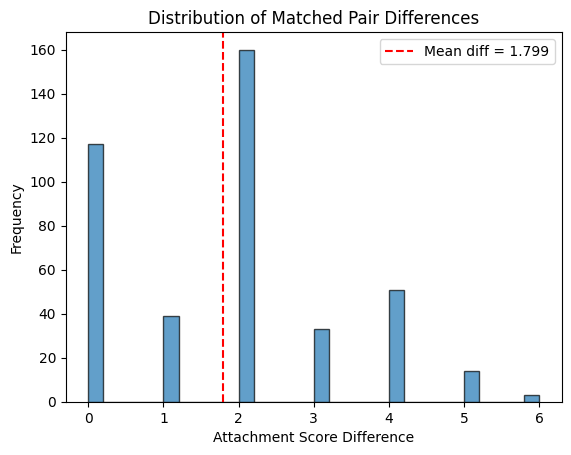

In [ ]:
diffs = treat_df['attachment_score'].values - ctrl_df['attachment_score'].values[matched_ctrl_idx[:len(treat_df)]]
plt.hist(diffs, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(np.mean(diffs), color='red', linestyle='--', label=f"Mean diff = {np.mean(diffs):.3f}")
plt.title("Distribution of Matched Pair Differences")
plt.xlabel("Attachment Score Difference")
plt.ylabel("Frequency")
plt.legend()
plt.show()